# Mapping mouse WTchim to atlas

Atlas is big enough to crash the notebook so try out different partitions?

### Load packages

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
})

### I/O

In [2]:
# out folder
in_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mb2338/annabelle/12_march/"
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mb2338/annabelle/12_march/haem/"
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/haem/plots/"

### Load data

In [3]:
big_sce <- readRDS(paste0(in_folder,"big_sce.rds"))
big_meta <- read.table(paste0(in_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [13]:
big_meta

cell,barcode,sample,stage,sequencing.batch,stripped,doublet,stage.mapped,celltype.mapped,closest.cell,tdTom,haem_subclust,celltype
<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
atlas_cell_1,AAAGGCCTCCACAA,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA
atlas_cell_2,AACAAACTCGCCTT,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA
atlas_cell_5,AACAGAGAATCAGC,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA
atlas_cell_6,AACATATGAATCGC,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA
atlas_cell_8,AACCGATGGCTTCC,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA
atlas_cell_9,AACGTGTGCTCTAT,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA
atlas_cell_10,AACTGTCTTCGCAA,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA
atlas_cell_11,AAGAACGACCAATG,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA
atlas_cell_12,AAGATGGACATTGG,atlas_1,E6.5,1,FALSE,FALSE,NA,NA,NA,NA,NA,NA


In [6]:
big_meta$haem_subclust <- NA

In [12]:
#big_meta$haem_subclust <- big_meta %>% filter() %>% select
big_meta$celltype <- NA
big_meta$celltype = as.character(big_meta$celltype.mapped[match(names(big_meta$cell), big_meta$closest.cell))])

In [31]:
big_meta$celltype <- big_meta %>% filter(big_meta$closest.cell %in% big_meta$cell) %>% .$celltype.mapped

ERROR: Error in `$<-.data.frame`(`*tmp*`, celltype, value = c("Haematoendothelial progenitors", : replacement has 13481 rows, data has 129793


In [14]:
unique(test$celltype)

[1] NA

In [9]:
test <- big_meta[!is.na(big_meta$haem_subclust),]
unique(test$haem_subclust)
unique(test$celltype)

[1] "ExE ectoderm"                   "Haematoendothelial progenitors"
 [3] "Surface ectoderm"               "Intermediate mesoderm"         
 [5] "Rostral neurectoderm"           "Mesenchyme"                    
 [7] "Nascent mesoderm"               "Def. endoderm"                 
 [9] "Visceral endoderm"              "ExE endoderm"                  
[11] "Blood progenitors 1"            "ExE mesoderm"                  
[13] "Primitive Streak"               "Notochord"                     
[15] "Forebrain/Midbrain/Hindbrain"   "Anterior Primitive Streak"     
[17] "Epiblast"                       "Parietal endoderm"             
[19] "Blood progenitors 2"            "Mixed mesoderm"                
[21] "Pharyngeal mesoderm"            "Gut"                           
[23] "Caudal epiblast"                "PGC"                           
[25] "Caudal Mesoderm"                "Caudal neurectoderm"           
[27] "Somitic mesoderm"               "Paraxial mesoderm"             
[29] "Allantois"                      "Erythroid1"                    
[31] "Cardiomyocytes"                 "Erythroid2"                    
[33] "Spinal cord"                    "NMP"                           
[35] "Endothelium"                    "Erythroid3"                    
[37] "Neural crest"

[1] NA

#### Quality filter cells & retain only haem

In [4]:
# extract cells to keep
haem_lineages = c('Erythroid3','Haematoendothelial progenitors','Erythroid2','Endothelium','Blood progenitors 2','Erythroid1','Blood progenitors 1')
keep <- big_meta %>% filter(stripped == FALSE & doublet == FALSE & celltype.mapped %in% haem_lineages | celltype.mapped %in% haem_lineages) %>% .$cell
# keep only those cells in big_sce
big_sce <- big_sce[, keep]
# save big_sce
saveRDS(big_sce, file = paste0(out_folder,"big_sce.rds"))

In [5]:
# clean meta
big_meta <- big_meta %>% filter(stripped == FALSE & doublet == FALSE & celltype %in% haem_lineages | celltype.mapped %in% haem_lineages)
# save meta after cleaning
write.table(big_meta, file = paste0(out_folder,"big_meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [6]:
# confirm SCE and metadata still overlap
summary(big_meta$cell == colnames(big_sce))

   Mode    TRUE 
logical   19663 

#### Normalize

In [7]:
# calculate sizefactors
clusts = as.numeric(quickCluster(big_sce, method = "igraph", min.size = 100, BPPARAM = mcparam))
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
big_sce = computeSumFactors(big_sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)
write.table(sizeFactors(big_sce), quote = F, col.names = F, row.names = F, file = paste0(out_folder,"sizefactors_big.tab"))

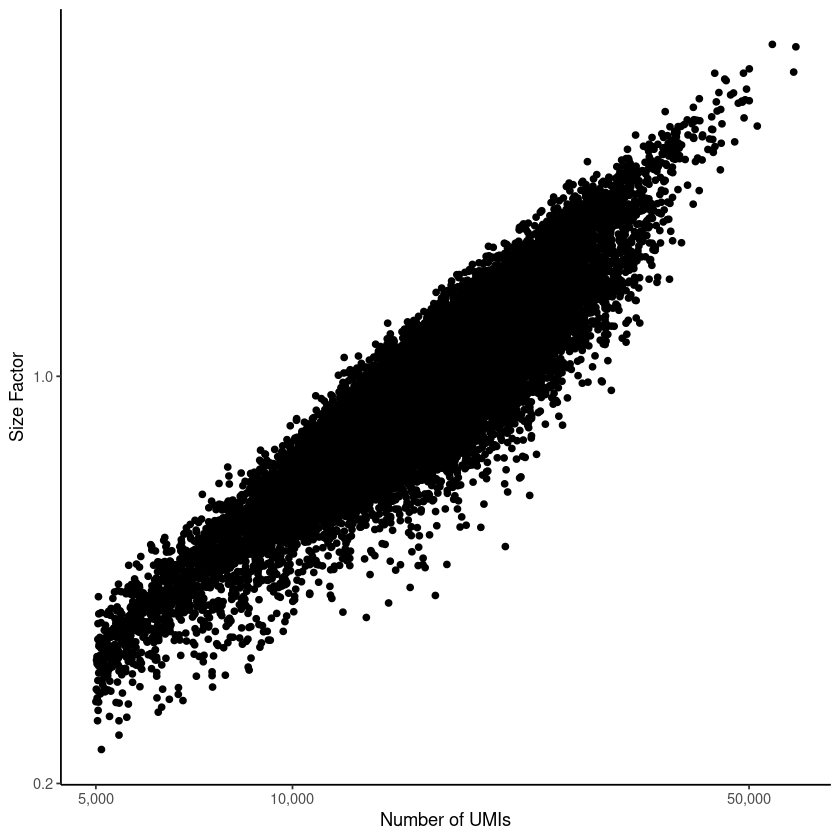

In [8]:
lib.sizes = Matrix::colSums(counts(big_sce))
ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(big_sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") + 
    theme_classic()

In [9]:
# Normalize
sfs = read.table(paste0(out_folder,"sizefactors_big.tab"), stringsAsFactors = F)[,1]
sizeFactors(big_sce) = sfs
big_sce = scater::logNormCounts(big_sce)

In [10]:
# save normalized sce
saveRDS(big_sce, file = paste0(out_folder,"big_sce_norm.rds"))

#### HVGs

In [11]:
big_sce <- readRDS(paste0(out_folder, "big_sce_norm.rds"))

In [12]:
# ygenes
ygenes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/ygenes.tab"

In [13]:
# load genes
ychr_e = read.table(ygenes_in, stringsAsFactors = F)[,1]
genes_meta = read.table(paste0(in_folder,"big_genes.tab"), stringsAsFactors = F)
rownames(genes_meta) = genes_meta$V1

# filter sex genes (Xist + ygenes)
paste0('genes before filtering: ', length(rownames(big_sce)))
big_sce   <- big_sce[!rownames(big_sce) %in% c('ENSMUSG00000086503', ychr_e),]
paste0('genes after filtering: ', length(rownames(big_sce)))

[1] "genes before filtering: 31217"

[1] "genes after filtering: 30483"

In [14]:
p.val_th = 0.05 # p-value threshold

# determine top HVGs
dec <- modelGeneVar(big_sce)
hvg_p <- getTopHVGs(dec, fdr.threshold = p.val_th)
paste0('number of HVGs based on P value: ', length(hvg_p))
hvg_n <- getTopHVGs(dec, n = 3000)

# save
write.csv(hvg_p, file =  paste0(out_folder,"big_hvgs_p.csv"))
write.csv(hvg_n, file =  paste0(out_folder,"big_hvgs_3000.csv"))

[1] "number of HVGs based on P value: 286"

#### Batch correction

In [15]:
BPPARAM = SerialParam()

# I/O
big_sce <- readRDS(paste0(out_folder, "big_sce_norm.rds"))
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
hvgs = read.csv(paste0(out_folder,"big_hvgs_3000.csv"))$x

In [16]:
#### Cosine normalisation ##### 
# add metadata combining stage & sample
big_meta$comb <- paste0(big_meta$stage, "_", big_meta$sample)

# extract counts for each combination
mat_temp = logcounts(big_sce)
mat = mat_temp[hvgs,]

# seperate count matrices based on combination
comb <- list()
for(i in unique(big_meta$comb)){
    comb[[i]] <- mat[, big_meta$comb == i]
}
paste0('nr of combinations: ', length(comb))

# cosine normalize
comb_cos <- list()
for(i in 1:length(comb)){
    comb_cos[[i]] <- cosineNorm(comb[[i]])
}

[1] "nr of combinations: 39"

In [17]:
######## from here on everything takes a while so may be better to run in Rscript rather than notebook
#### calculate PCs #####
big_pca = multiBatchPCA(comb_cos ,BPPARAM = BPPARAM,d = 50)

In [18]:
saveRDS(big_pca, file=paste0(out_folder, 'uncorrected_PCs_multibatch.rds'))
big_pca <- do.call(rbind, big_pca)
saveRDS(big_pca, file=paste0(out_folder, 'uncorrected_PCs.rds'))

### pay attention from here!!

In [19]:
big_pca <- readRDS(paste0(out_folder, 'uncorrected_PCs.rds'))
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [20]:
# give chimaera different stage value to make batch correction easier
big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1)
big_meta$stage[which(big_meta$origin == "chim")] <- 'E8.5_chim'

In [21]:
#### reducedMNN preparation ##### (run in next cell)
set.seed(42)
# over several iterations 

# order of batch corrections --> input chimaera as seperate timepoint to make looping easier
#### This way chimaera's will still be batch corrected separately from atlas.
order_df = big_meta[!duplicated(big_meta$sample), c("stage", "sample")]
order_df$ncells = sapply(order_df$sample, function(x) sum(big_meta$sample == x))
order_df$stage = factor(order_df$stage,
                          levels = rev(c("E8.5",  ##### this may not work this time since we have every timepoint --> remove those with no samples in them
                                         "E8.25", 
                                         "E8.0", 
                                         "E7.75", 
                                         "E7.5", 
                                         "E7.25", 
                                         "mixed_gastrulation", 
                                         "E7.0", 
                                         "E6.75", 
                                         "E6.5",
                                         "E8.5_chim"))) # Chimaera last!
order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage = as.character(order_df$stage)
order_df$comb <- paste0(order_df$stage, "_", order_df$sample)

# defenitions for creating nested lists                         
timepoints = big_meta$stage
samples = big_meta$sample
timepoint_order = order_df$stage
sample_order = order_df$sample

#create nested list
  pc_list = lapply(unique(timepoints), function(tp){
    sub_pc = big_pca[timepoints == tp, , drop = FALSE]
    sub_samp = samples[timepoints == tp]
    list = lapply(unique(sub_samp), function(samp){
     sub_pc[sub_samp == samp, , drop = FALSE]
    })
    names(list) = unique(sub_samp)
    return(list)
  })

  names(pc_list) = unique(timepoints)

  #arrange to match timepoint order
  pc_list = pc_list[order(match(names(pc_list), timepoint_order))]
  pc_list = lapply(pc_list, function(x){
    x[order(match(names(x), sample_order))]
  })

# create if statement for following numbers in next cell:
print('create if statement for following values: ')
    for(i in 1:length(pc_list)){
    print(length(pc_list[[i]]))
}

[1] "create if statement for following values: "
[1] 4
[1] 3
[1] 4
[1] 4
[1] 6
[1] 3
[1] 2
[1] 6
[1] 1
[1] 6


In [22]:
# reducedMNN within timepoints
# reducedMNN is too stupid to understand looping over list so each list element has to be inputted as seperate object
# done with if statement so you don't have to write a seperate line for each nested list
corrected_pcs <- list()
for(i in 1:length(pc_list)){
    if(length(pc_list[[i]]) == 1){
        corrected_pcs[[i]] <- unlist(pc_list[[i]][[1]])
    }
    if(length(pc_list[[i]]) == 2){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 3){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 4){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 5){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 6){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]], pc_list[[i]][[6]],BPPARAM = SerialParam())$corrected
    }
    if(length(pc_list[[i]]) == 10){
        corrected_pcs[[i]] <- reducedMNN(pc_list[[i]][[1]], pc_list[[i]][[2]], pc_list[[i]][[3]],pc_list[[i]][[4]], pc_list[[i]][[5]], pc_list[[i]][[6]],pc_list[[i]][[7]], pc_list[[i]][[8]], pc_list[[i]][[9]],pc_list[[i]][[10]],BPPARAM = SerialParam())$corrected
    }
}

saveRDS(corrected_pcs, file=paste0(out_folder, 'corrected_PCs_time_multibatch.rds'))
temp = do.call(rbind, corrected_pcs)
write.csv(temp, paste0(out_folder, 'corrected_pc_time.csv'))

Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”


In [23]:
nrow(temp) == nrow(big_meta) # sanity check if we still have the same amount of cells

[1] TRUE

In [24]:
#### Check which element in pc_list is chimaera!!
# all before that should be merged with atlas
head(pc_list[[10]][[1]])

chim_cell_2,-0.3678663,-0.12831515,-0.019755588,-0.02072619,-0.041407856,0.005668602,0.0047471953,-0.0012146869,0.0237818257,-0.013462645,⋯,-0.004690628,-0.001916259,0.0121737443,0.0119514240,-0.011488199,-0.011045682,0.0009124111,0.004791638,-0.0057998842,-0.012393610
chim_cell_8,-0.3636280,-0.12120548,-0.020883800,-0.02114076,-0.050885405,0.015820205,-0.0021403842,0.0077602543,-0.0009523884,-0.006448398,⋯,-0.007409928,0.004194626,-0.0007980831,-0.0007371569,-0.006773412,-0.006127364,-0.0049856861,-0.004886991,0.0003893368,-0.004751586
chim_cell_10,-0.3430219,-0.10897326,-0.019798051,-0.01044511,-0.021069446,0.009034295,0.0183478704,0.0055712633,0.0160406693,-0.016110956,⋯,0.006137664,0.017407392,0.0032438973,0.0061006107,-0.002855715,-0.005930768,0.0030292404,0.002102196,-0.0057339333,0.011986368
chim_cell_12,-0.2939923,-0.09508229,0.020528495,-0.04756583,-0.003613296,-0.017004631,-0.0001365382,0.0126666069,-0.0163670009,0.017285034,⋯,-0.006394539,0.000951609,0.0129392726,0.0001156298,0.007780632,-0.014940051,-0.0142976952,-0.010187140,0.0003020272,-0.003834635
chim_cell_13,-0.3321009,-0.11788299,0.005688014,-0.01206577,-0.040791767,0.002573428,-0.0063581584,0.0032323869,-0.0220238891,-0.003457312,⋯,-0.004361393,-0.005707288,-0.0005726179,0.0086582844,0.005509412,-0.017775398,-0.0035741419,0.001892698,-0.0087565050,0.009161131
chim_cell_18,-0.3347955,-0.12451003,0.017054111,-0.03354535,-0.031025198,0.013482883,0.0160527701,0.0007185295,0.0287402050,-0.033662802,⋯,-0.012902046,0.011068961,0.0057575448,0.0067426764,0.007460338,-0.009839001,-0.0112767822,-0.003051312,-0.0062960618,-0.002779194


In [25]:
# correct across timepoints of atlas only (corrected_pcs 1 - 9)
correct_atlas = reducedMNN(corrected_pcs[[1]], corrected_pcs[[2]], corrected_pcs[[3]],corrected_pcs[[4]], corrected_pcs[[5]], corrected_pcs[[6]],corrected_pcs[[7]], corrected_pcs[[8]], corrected_pcs[[9]], BPPARAM = SerialParam())$corrected

Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”


In [26]:
# correct atlas + chimaera
correct_complete = reducedMNN(correct_atlas, corrected_pcs[[10]], BPPARAM = SerialParam())$corrected
# save temp corrected PCs
write.csv(correct_complete, paste0(out_folder, 'corrected_pc_complete_unordered.csv')) 

In [27]:
correct_complete_bu <- correct_complete

In [28]:
correct_complete <- correct_complete_bu

In [29]:
#### don't fuck up the naming of PCs ---> should be fine but maybe check intermediate steps before running



# order pcs according to metadata
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
cells <- big_meta$cell
keyDF <- data.frame(key=cells,weight=1:length(cells))
correct_complete <- as.data.frame(correct_complete)
correct_complete$cell <- rownames(correct_complete)
merged <- merge(correct_complete,keyDF,by.x='cell',by.y='key',all.x=T,all.y=T)
correct_complete <- merged %>% arrange(weight)
correct_complete$weight <- NULL
rownames(correct_complete) <- correct_complete$cell
correct_complete$cell <- NULL

In [30]:
# save final corrected PCs
write.csv(correct_complete, paste0(out_folder, 'corrected_pc_complete.csv')) 

### UMAP visualisation

In [31]:
# Load in data
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
pca_before = as.data.frame(readRDS(paste0(out_folder, 'uncorrected_PCs.rds')))
pca_before$cell <- rownames(pca_before)
pca_after = as.data.frame(read.csv(paste0(out_folder, 'corrected_pc_complete.csv'), header=T, row.names=1,sep=","))
pca_after$cell <- rownames(pca_after)

In [32]:
# add metadata to PCs
pca_before <- merge(pca_before, big_meta, by='cell')
rownames(pca_before) <- pca_before$cell
pca_after <- merge(pca_after, big_meta, by='cell')
rownames(pca_after) <- pca_after$cell

In [33]:
# calculate umap's on whole object and chimeara seperately
### chimaera only
# before correction
pca_before$origin <- sapply(strsplit(pca_before$cell,"_"), `[`, 1)
chim_before <- pca_before %>% filter(origin=='chim') %>% select(2:51) # Use all 50 PCs for UMAP
chim_before_umap = umap(t(chim_before))$data
chim_before_umap <- as.data.frame(chim_before_umap)
colnames(chim_before_umap) <- c('umap1','umap2')
chim_before_umap$cell <- rownames(chim_before)
chim_before_umap <- merge(chim_before_umap, big_meta, by='cell')
# write
write.csv(chim_before_umap, paste0(out_folder, 'umap_before_correction_chim.csv')) 
print('finished first umap')


# after correction
pca_after$origin <- sapply(strsplit(pca_after$cell,"_"), `[`, 1)
chim_after <- pca_after %>% filter(origin=='chim') %>% select(2:51) 
chim_after_umap = umap(t(chim_after))$data
chim_after_umap<- as.data.frame(chim_after_umap)
colnames(chim_after_umap) <- c('umap1','umap2')
chim_after_umap$cell <- rownames(chim_after)
chim_after_umap <- merge(chim_after_umap, big_meta, by='cell')
# write
write.csv(chim_after_umap, paste0(out_folder, 'umap_after_correction_chim.csv')) 
print('finished second umap')

### whole object
# before correction
pca_before$origin <- sapply(strsplit(pca_before$cell,"_"), `[`, 1)
pca_before <- pca_before %>% select(2:51)
pca_before_umap = umap(t(pca_before))$data
pca_before_umap <- as.data.frame(pca_before_umap)
colnames(pca_before_umap) <- c('umap1','umap2')
pca_before_umap$cell <- rownames(pca_before)
pca_before_umap <- merge(pca_before_umap, big_meta, by='cell')
# write
write.csv(pca_before_umap, paste0(out_folder, 'umap_before_correction.csv')) 
print('finished third umap')

# after correction
pca_after$origin <- sapply(strsplit(pca_after$cell,"_"), `[`, 1)
pca_after <- pca_after %>% select(2:51)
pca_after_umap = umap(t(pca_after))$data
pca_after_umap <- as.data.frame(pca_after_umap)
colnames(pca_after_umap) <- c('umap1','umap2')
pca_after_umap$cell <- rownames(pca_after)
pca_after_umap <- merge(pca_after_umap, big_meta, by='cell')
# write
write.csv(pca_after_umap, paste0(out_folder, 'umap_after_correction.csv')) 
print('finished fourth umap')

***UMAP wrapper function***

running...

done.



[1] "finished first umap"


***UMAP wrapper function***

running...

done.



[1] "finished second umap"


***UMAP wrapper function***

running...

done.



[1] "finished third umap"


***UMAP wrapper function***

running...

done.



[1] "finished fourth umap"


In [34]:
# load in data
chim_before_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_before_correction_chim.csv'), header=T, row.names=1,sep=","))
chim_after_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction_chim.csv'), header=T, row.names=1,sep=","))
pca_before_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_before_correction.csv'), header=T, row.names=1,sep=","))
pca_after_umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=","))

In [72]:
# plot umaps

# colors
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")

# chimaera
options(repr.plot.width = 10, repr.plot.height = 5)
p1 <- ggplot(chim_before_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('chimaera only, before correction, color = samples')
p2 <- ggplot(chim_before_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('chimaera only, before correction, color =  tomato')

p3 <- ggplot(chim_after_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('chimaera only, after correction, color = samples')
p4 <- ggplot(chim_after_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('chimaera only, after correction, color = tomato')

# whole object
p5 <- ggplot(pca_before_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('whole object before correction, color = sample')
p6 <- ggplot(pca_after_umap, aes(umap1, umap2, color=sample)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('whole object after correction, color = sample')

p7 <- ggplot(pca_before_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('whole object before correction, color = tomato')
p8 <- ggplot(pca_after_umap, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('whole object after correction, color = tomato')

p9 <- ggplot(pca_before_umap, aes(umap1, umap2, color=stage)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    scale_colour_manual(values = stage_colours, labels = stage_labels, name = "stage") +
    ggtitle('whole object before correction, color = timepoint')
p10 <- ggplot(pca_after_umap, aes(umap1, umap2, color=stage)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    scale_colour_manual(values = stage_colours, labels = stage_labels, name = "stage") +
    ggtitle('whole object after correction, color = timepoint')

atlas_before_umap <- pca_before_umap %>% filter(!is.na(celltype))
p11 <- ggplot(atlas_before_umap, aes(umap1, umap2, color=celltype)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    ggtitle('atlas only before correction, color = celltype')
atlas_after_umap <- pca_after_umap %>% filter(!is.na(celltype))
p12 <- ggplot(atlas_after_umap, aes(umap1, umap2, color=celltype)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
    ggtitle('atlas only after correction, color = celltype')

pca_before_85 <- pca_before_umap %>% filter(stage == 'E8.5')
p13 <- ggplot(pca_before_85, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('E8.5 before correction, color = tomato')
pca_after_85 <- pca_after_umap %>% filter(stage == 'E8.5')
p14 <- ggplot(pca_after_85, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.4, size = 0.8) +
    theme_classic() +
    ggtitle('E8.5 after correction, color = tomato')

pca_before_umap$origin <- sapply(strsplit(pca_before_umap$cell,"_"), `[`, 1)
p15 <- ggplot(pca_before_umap, aes(umap1, umap2, color= origin)) +
    geom_point(alpha=0.2, size = 0.8) +
    theme_classic() +
    ggtitle('whole object after correction, color = experiment')
pca_after_umap$origin <- sapply(strsplit(pca_after_umap$cell,"_"), `[`, 1)
p16 <- ggplot(pca_after_umap, aes(umap1, umap2, color= origin)) +
    geom_point(alpha=0.2, size = 0.8) +
    theme_classic() +
    ggtitle('whole object after correction, color = experiment')

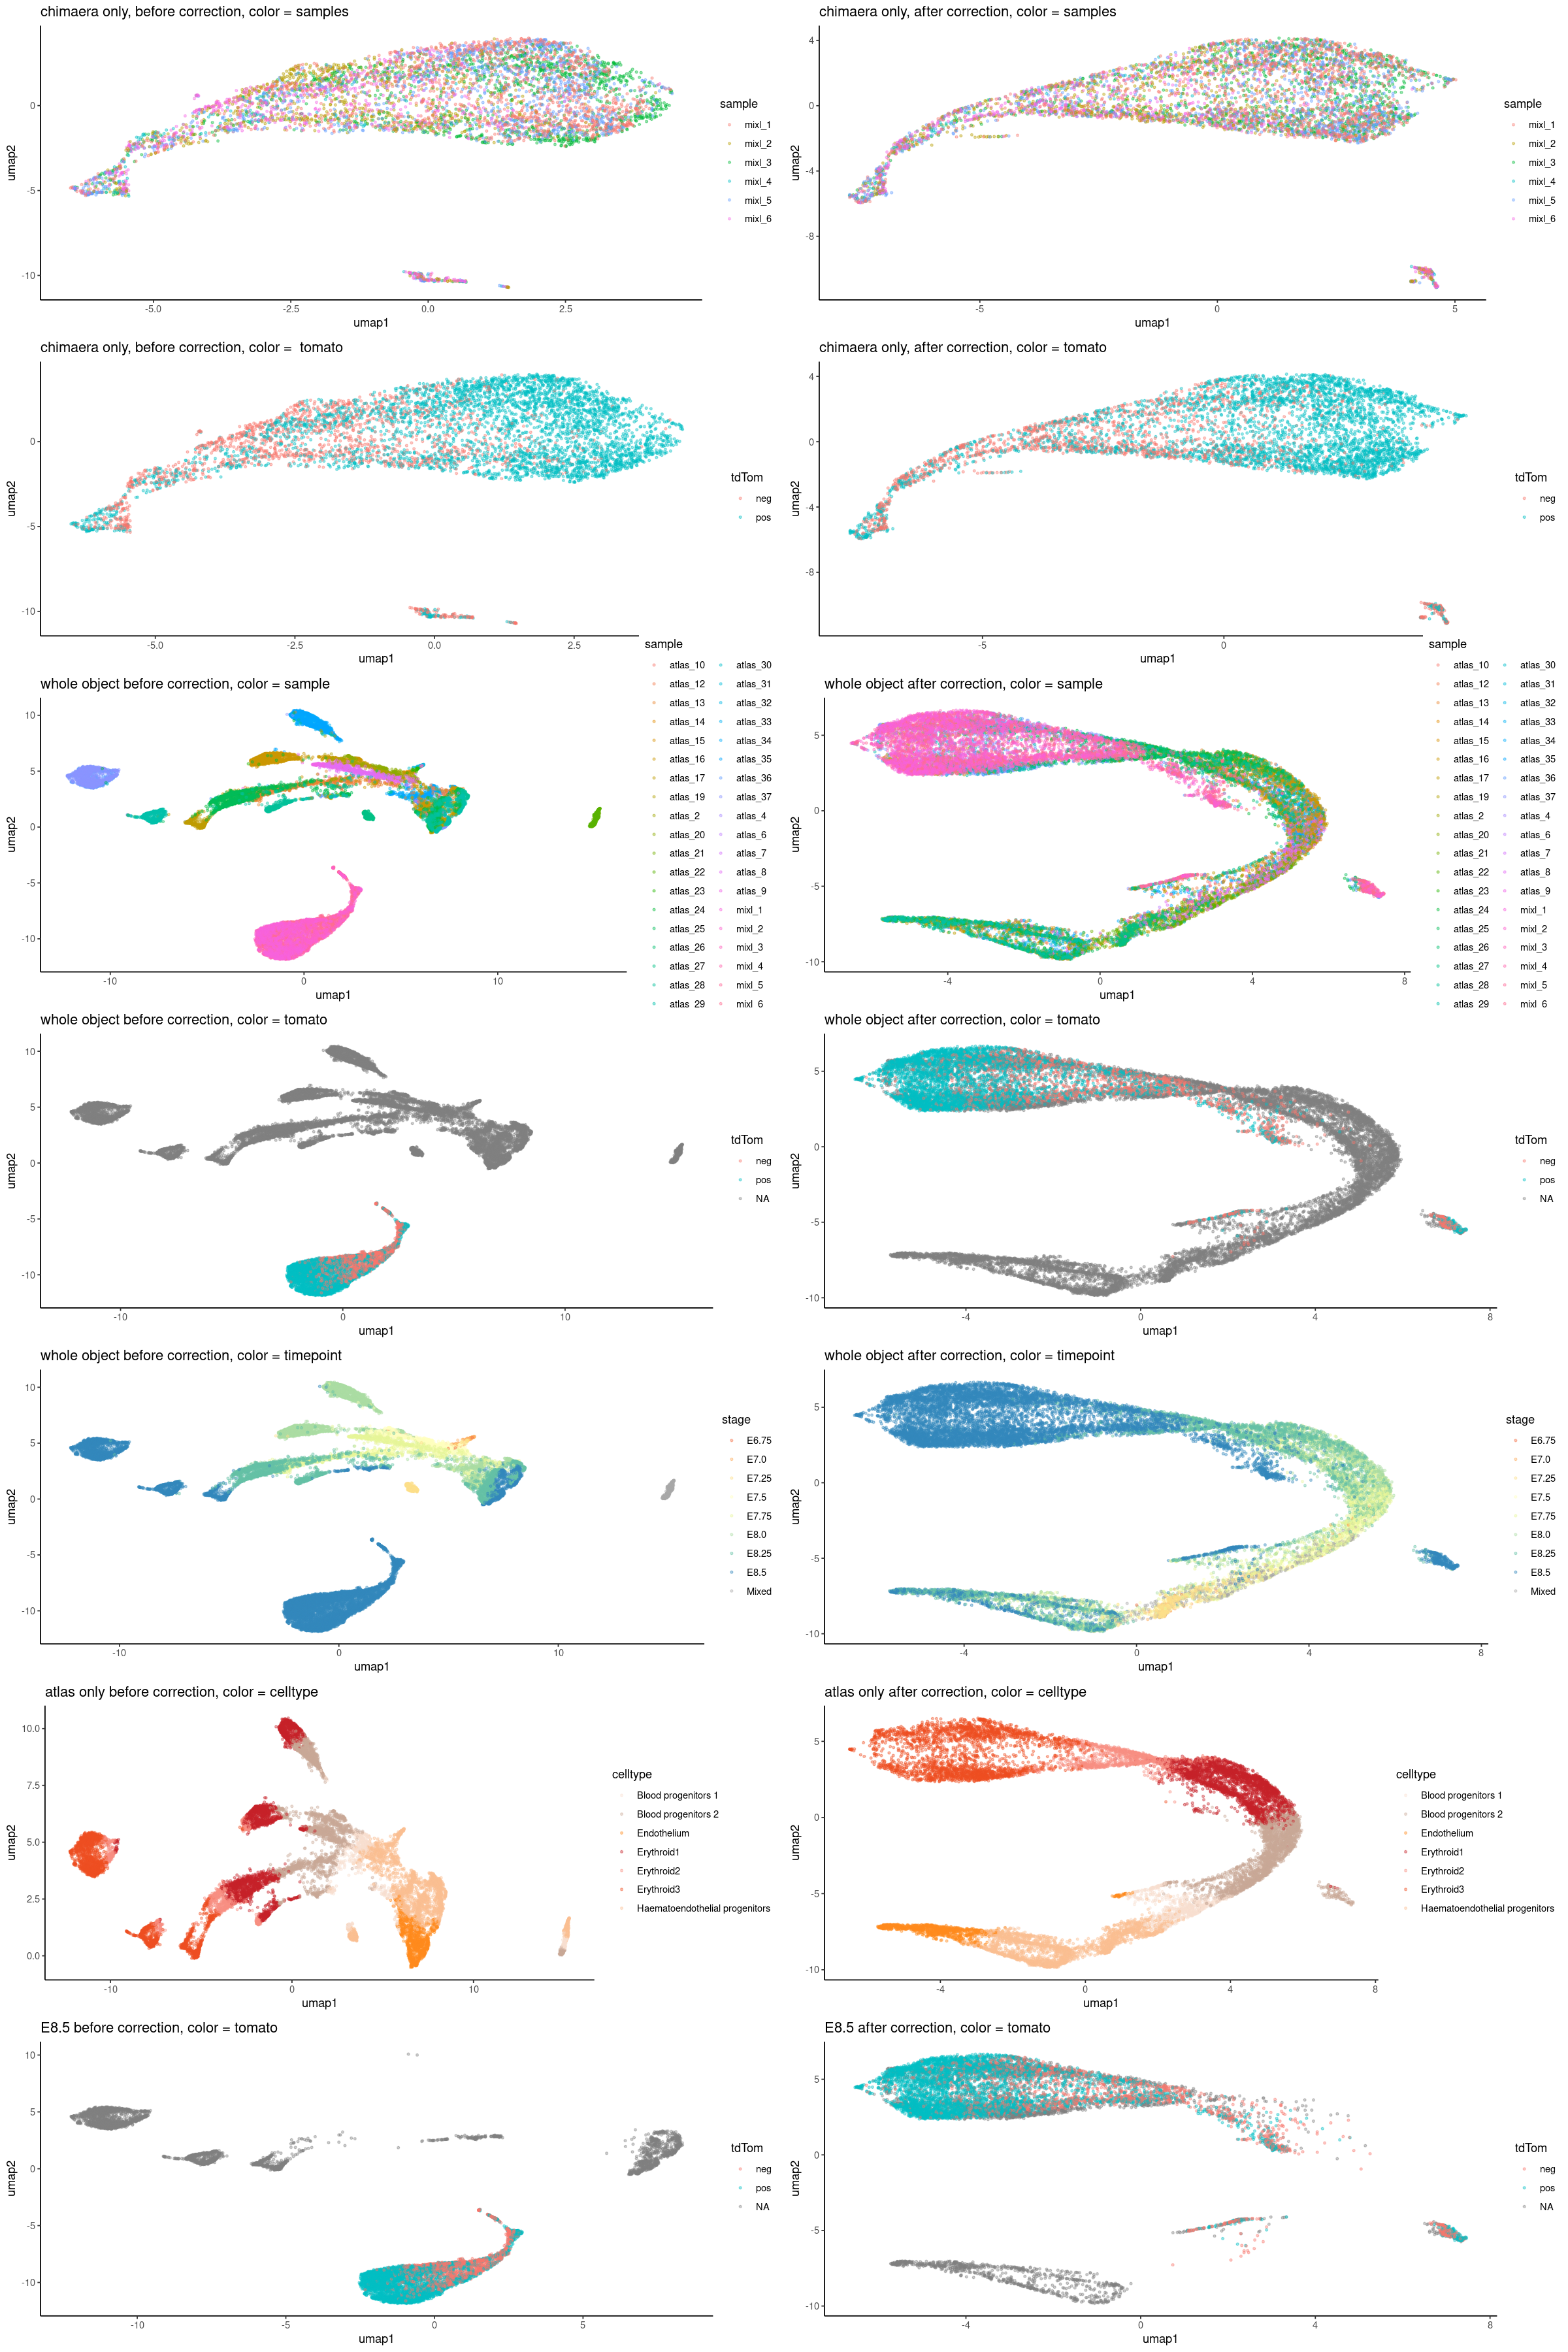

In [73]:
options(repr.plot.width = 20, repr.plot.height = 30)
    grid.arrange(p1, p3, p2, p4, p5, p6, p7, p8, p9, p10, p11, p12, p13, p14, nrow =7)

In [74]:
# plot to png instead of pdf to stop laptop from burning
png(paste0(plot_folder, "umap_batch_correction_comparisons.png"), height=5000, width=3500)
    grid.arrange(p1, p3, p2, p4, p5, p6, p7, p8, p9, p10, p11, p12, p13, p14, nrow =7)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_chimaera.png"), height=1000, width=1000)
    grid.arrange(p1, p3, p2, p4, nrow =2)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_sample.png"), height=1000, width=2500)
    grid.arrange(p5, p6, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_tomato.png"), height=1000, width=2500)
    grid.arrange(p7, p8, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_timepoint.png"), height=1000, width=2500)
    grid.arrange(p9, p10, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_celltype.png"), height=1000, width=2500)
    grid.arrange(p11, p12, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_correction_comparisons_E85.png"), height=1000, width=2500)
    grid.arrange(p13, p14, nrow =1)
dev.off()

png(paste0(plot_folder, "umap_batch_corrected_plots.png"), height=2000, width=3500)
    grid.arrange(p6, p8, p12, p10, nrow =2)
dev.off()

png(paste0(plot_folder, "umap_batch_corrected_origin.png"), height=1000, width=2500)
    grid.arrange(p15, p16, nrow =1)
dev.off()

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

png 
  2

In [38]:
pca_after_85 <- pca_after_umap %>% filter(stage == 'E8.5')
p14 <- ggplot(pca_after_85, aes(umap1, umap2, color=tdTom)) +
    geom_point(alpha=0.2, size = 1, color='grey') +
    geom_point(data=pca_after_85, aes(umap1, umap2, color=tdTom),alpha=0.2, size = 1) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) +
    ggtitle('E8.5 only, color = tomato')

Warning message:
“Removed 3892 rows containing missing values (geom_point).”


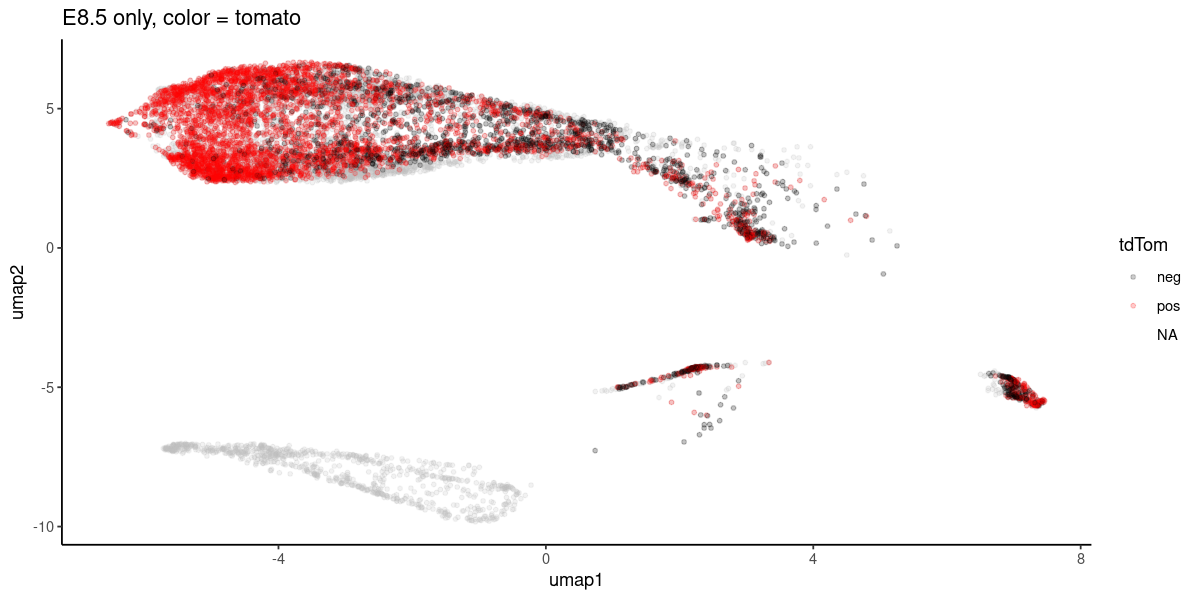

In [39]:
options(repr.plot.width = 10, repr.plot.height = 5)
p14

In [40]:

png(paste0(plot_folder, "umap_85_tomato.png"), height=1000, width=1300)
    grid.arrange(p14)
dev.off()


Warning message:
“Removed 3892 rows containing missing values (geom_point).”


png 
  2

#### Map

In [3]:
# Load in data
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
pca_after = as.data.frame(read.csv(paste0(out_folder, 'corrected_pc_complete.csv'), header=T, row.names=1,sep=","))
pca_after$cell <- rownames(pca_after)

In [4]:
# label origin in metdata
big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1) 

In [5]:
# split atlas and chimaera
atlas_cells = big_meta %>% filter(origin=='atlas') %>% .$cell
correct_atlas = pca_after %>% filter(cell %in% atlas_cells)
atlas_meta = big_meta %>% filter(origin=='atlas')
correct_map = pca_after %>% filter(!cell %in% atlas_cells) %>% select(1:50) # keep only PC columns
map_meta = big_meta %>% filter(origin!='atlas') 

In [6]:
# Downsample atlas to 10k cells per timepoint
keep = lapply(unique(atlas_meta$stage), function(x){
  if(x == "mixed_gastrulation"){
    return(atlas_meta[atlas_meta$stage == x,]$cell)
  } else if(sum(atlas_meta$stage == x) < 10000) {
    return(atlas_meta[atlas_meta$stage == x,]$cell)
  } else {
    return(atlas_meta[atlas_meta$stage == x,]$cell)
    return(sample(hits, 10000))
  }
})
keep = do.call(c, keep)
keep <- as.list(keep)

atlas_meta = atlas_meta %>% filter(cell %in% keep)
correct_atlas = correct_atlas %>% filter(cell %in% keep) %>% select(1:50)

In [9]:
atlas_meta$count = 1
test = atlas_meta %>% group_by(stage) %>% summarize(cells = sum(count))
test

`summarise()` ungrouping output (override with `.groups` argument)



stage,cells
<chr>,<dbl>
E6.75,3
E7.0,249
E7.25,310
E7.5,726
E7.75,2180
E8.0,3552
E8.25,2504
E8.5,3892
mixed_gastrulation,465


In [45]:
## standard mapping only on stage & celltype, add extra columns if you want to map them, e.g. haem_subclust
# indicated by ## ADD HERE

In [46]:
## Code for mapping:

getmode <- function(v, dist) {
  tab = table(v)
  #if tie, break to shortest distance
  if(sum(tab == max(tab)) > 1){
    tied = names(tab)[tab == max(tab)]
    sub = dist[v %in% tied]
    names(sub) = v[v %in% tied]
    return(names(sub)[which.min(sub)])
  } else {
    return(names(tab)[which.max(tab)])
  }
}

mnnMap = function(atlas_pca, atlas_meta, map_pca, map_meta, k_map = 10){
  require(BiocNeighbors)
  require(scran)
  
  knns = BiocNeighbors::queryKNN(correct_atlas, correct_map, k = k_map, get.index = TRUE, get.distance = FALSE)
  
  #get closest k matching cells
  k.mapped = t(apply(knns$index, 1, function(x) atlas_meta$cell[x]))
  celltypes = t(apply(k.mapped, 1, function(x) atlas_meta$celltype[match(x, atlas_meta$cell)]))
  stages = t(apply(k.mapped, 1, function(x) atlas_meta$stage[match(x, atlas_meta$cell)]))
  haem_subclust = t(apply(k.mapped, 1, function(x) atlas_meta$haem_subclust[match(x, atlas_meta$cell)]))
  celltype.mapped = apply(celltypes, 1, function(x) getmode(x, 1:length(x)))
  stage.mapped = apply(stages, 1, function(x) getmode(x, 1:length(x)))
  haem_subclust.mapped = apply(haem_subclust, 1, function(x) getmode(x, 1:length(x))) ## ADD HERE
  
  out = lapply(1:length(celltype.mapped), function(x){
    list(cells.mapped = k.mapped[x,],
         celltype.mapped = celltype.mapped[x],
         haem_subclust.mapped = haem_subclust.mapped[x],     ## ADD HERE
         stage.mapped = stage.mapped[x])
  })
  
  names(out) = map_meta$cell

  return(out)
  
}

In [47]:
# Perform mapping:
mapping = mnnMap(correct_atlas, atlas_meta, correct_map, map_meta, k_map = 10)
  
  cn = substr(names(mapping), 5, nchar(names(mapping))) # remove 
  ct = sapply(mapping, function(x) x$celltype.mapped)
  st = sapply(mapping, function(x) x$stage.mapped)
  hm = sapply(mapping, function(x) x$haem_subclust.mapped) ## ADD HERE
  closest = sapply(mapping, function(x) x$cells.mapped[1])
  
  out = data.frame(cell = cn, celltype.mapped = ct, stage.mapped = st, closest.cell = closest, haem_subclust.mapped = hm) ## ADD HERE
# save mapped celltypes
write.csv(out, paste0(out_folder, 'chimaera_mapped_celltypes.csv')) 

Loading required package: BiocNeighbors


Attaching package: ‘BiocNeighbors’


The following object is masked from ‘package:batchelor’:

    findMutualNN




In [48]:
### visualise mapping
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mapping <- read.csv(paste0(out_folder, 'chimaera_mapped_celltypes.csv'), row.names=1)
mapping$cell <- rownames(mapping)

# add cell mapping to metadata
big_meta$stage.mapped = as.character(mapping$stage.mapped[match(big_meta$cell, mapping$cell)])
big_meta$celltype.mapped = as.character(mapping$celltype.mapped[match(big_meta$cell, mapping$cell)])
big_meta$haem_subclust.mapped = as.character(mapping$haem_subclust.mapped[match(big_meta$cell, mapping$cell)]) ## ADD HERE
big_meta$closest.cell = as.character(mapping$closest.cell[match(big_meta$cell, mapping$cell)])

# only plot chimaera cells
meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

In [49]:
### save big meta with mapping
write.table(big_meta, file = paste0(out_folder,"big_meta_mapping.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [17]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")


In [4]:
big_meta = read.csv(paste0(out_folder,"big_meta_mapping.tab"), sep='\t')

In [10]:
big_meta$tdTom = NULL
big_meta$tdTom[big_meta$sample %in% c('mixl_1', 'mixl_3', 'mixl_5')] <- "neg"
big_meta$tdTom[big_meta$sample %in% c('mixl_2', 'mixl_4', 'mixl_6')] <- "pos"

meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

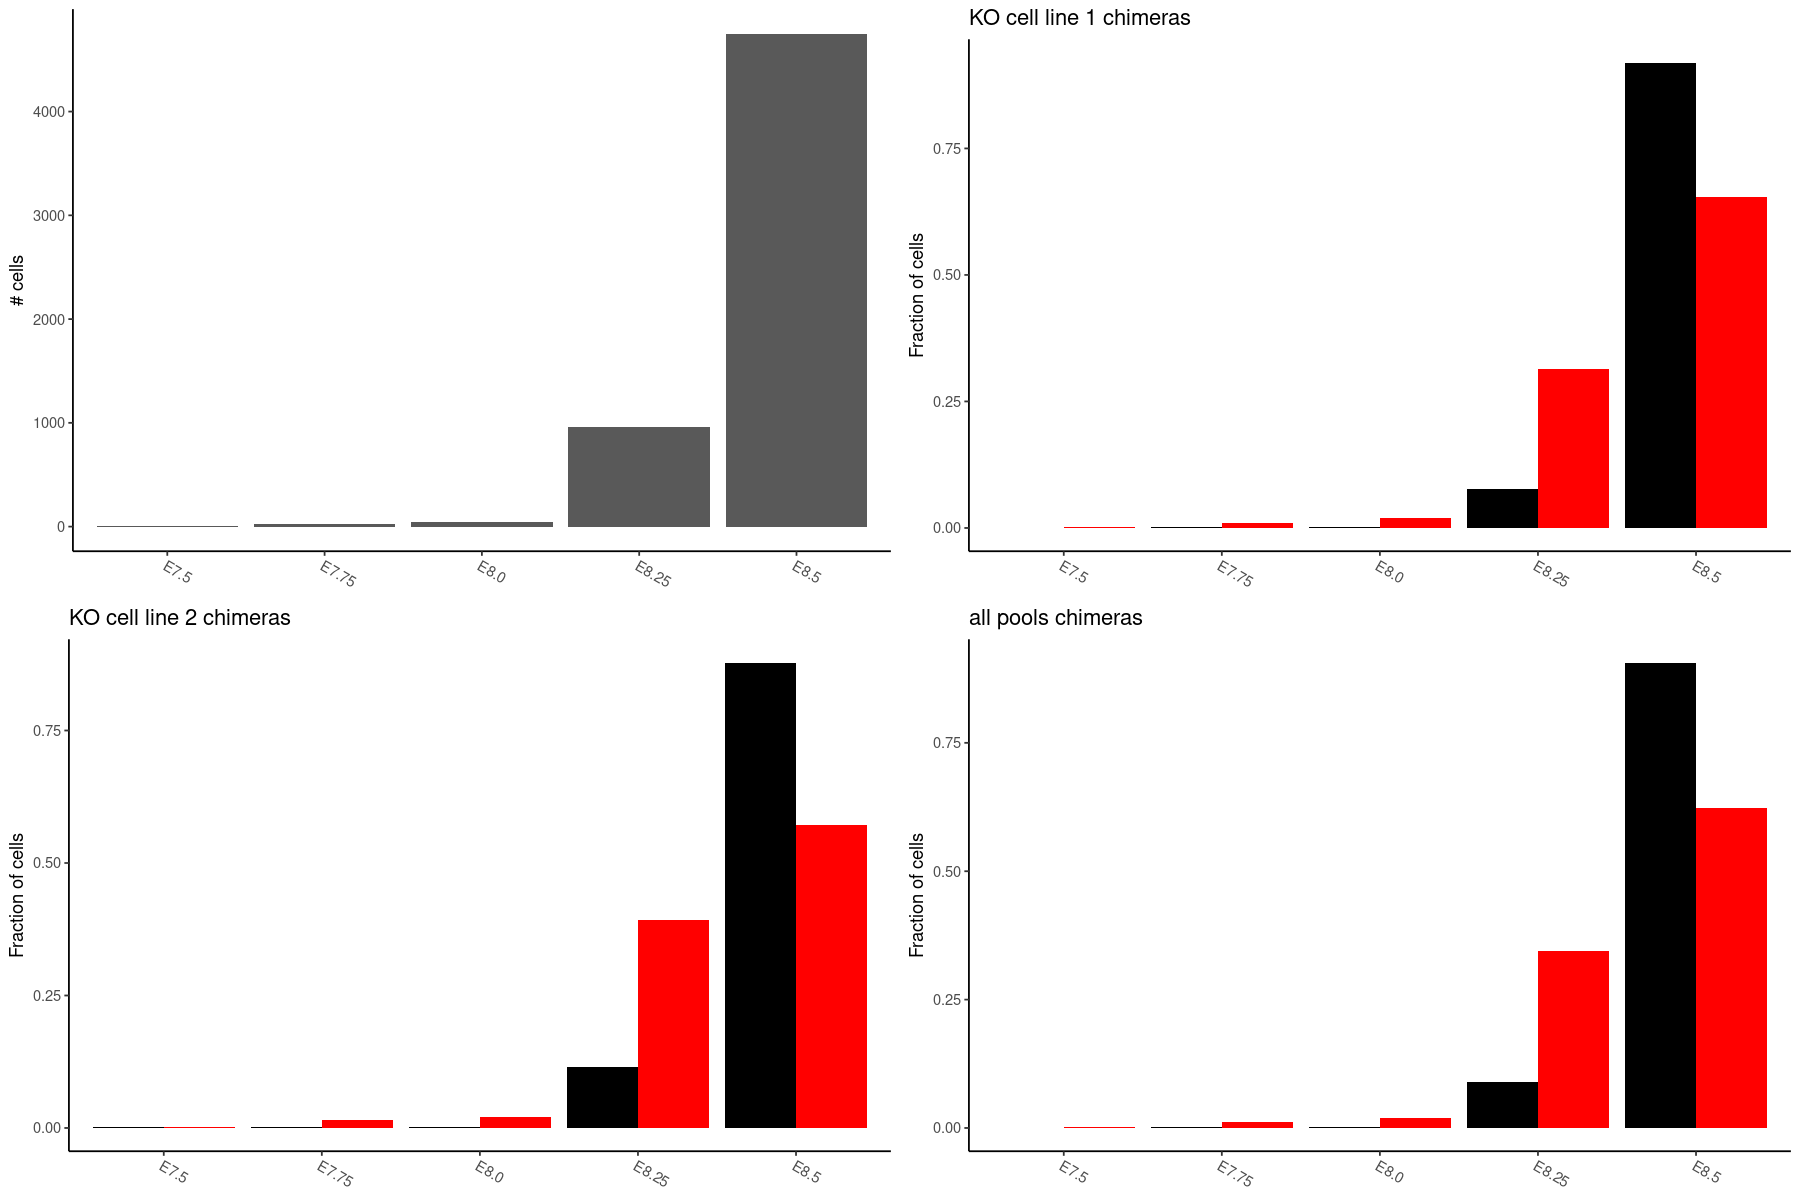

In [11]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4')
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$stage.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas stage", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])
  

pdf1 = table(meta$stage.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])


pdf2 = table(meta$stage.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$stage.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])

options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [12]:

pdf(paste0(plot_folder, "chimaera_stage_mapping.pdf"), height=8, width=10)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

png 
  2

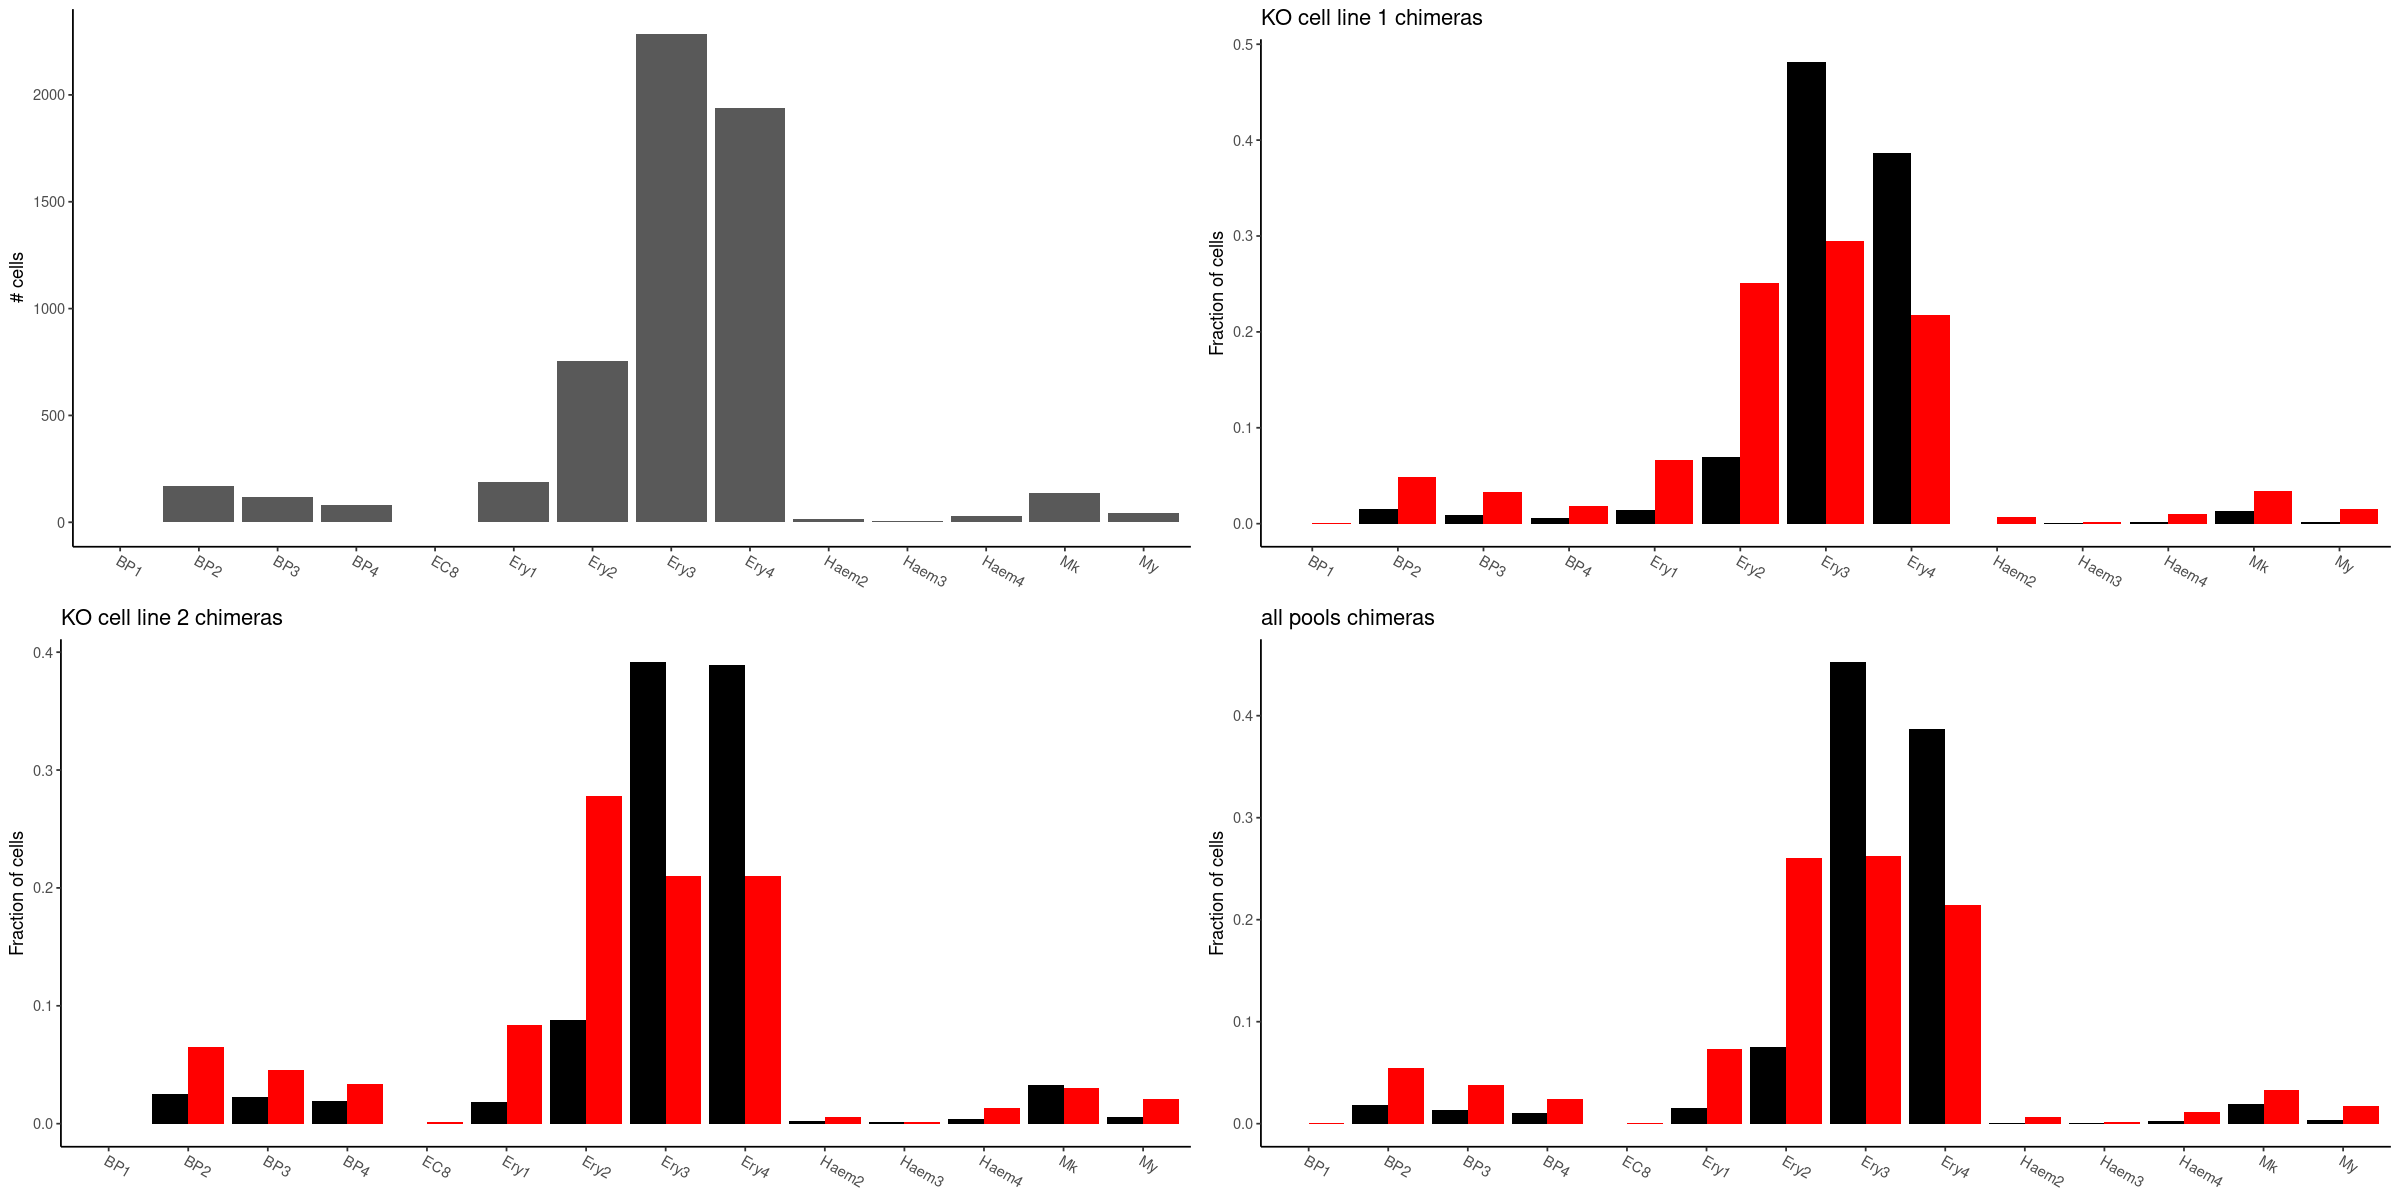

In [13]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$haem_subclust.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas haem_subclust", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))])
  
  

pdf1 = table(meta$haem_subclust.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))])


pdf2 = table(meta$haem_subclust.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$haem_subclust.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [15]:

pdf(paste0(plot_folder, "chimaera_celltype_mapping.pdf"), height=8, width=20)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

png 
  2

Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Transformation introduced infinite values in continuous y-axis”


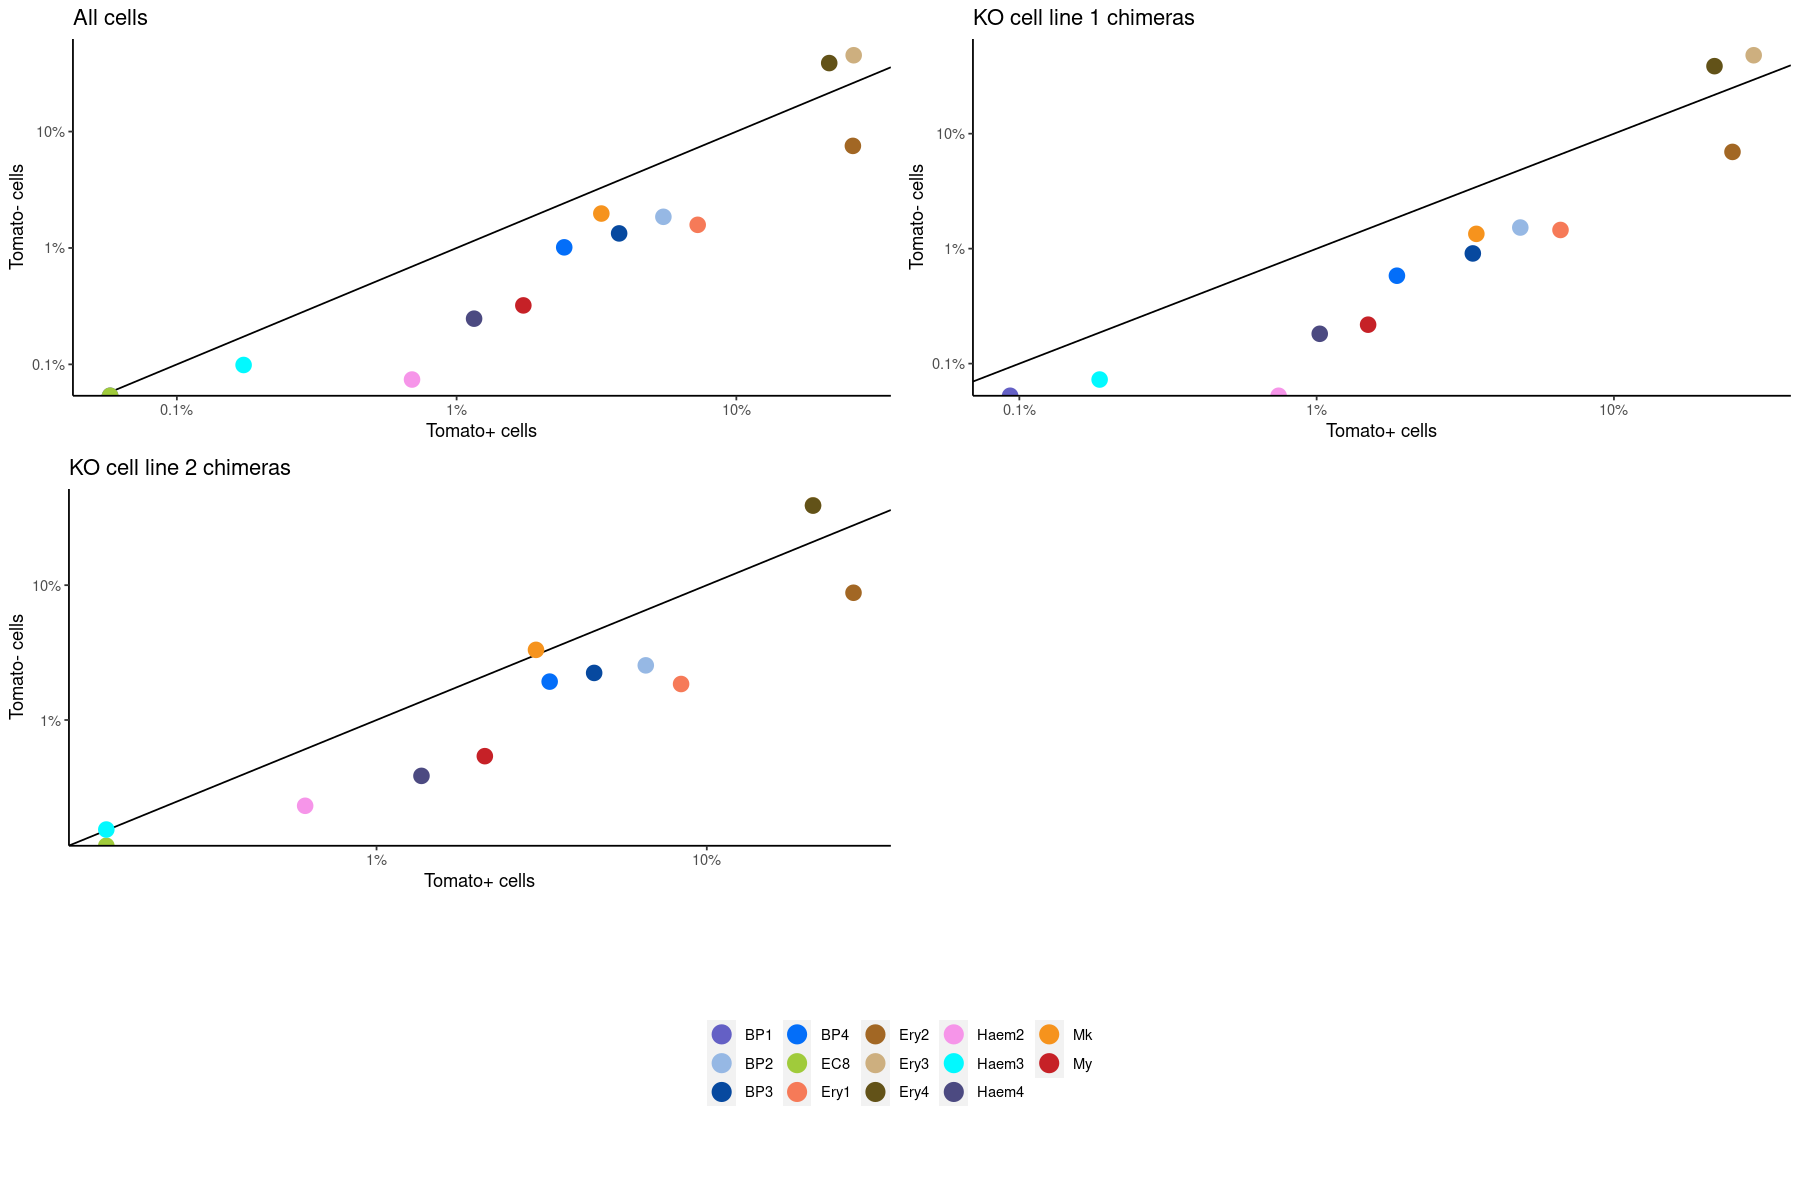

In [18]:
pdfall = table(meta$haem_subclust.mapped, meta$tdTom)
colnames(pdfall) = c("TomT", "TomF")[match(colnames(pdfall), c("pos", "neg"))]
pdfall = sweep(pdfall, 2, colSums(pdfall), "/")
pdfall = as.data.frame.matrix(pdfall)


plegend = ggplot(data = pdfall, mapping = aes(x = TomT, y = TomF, col = rownames(pdfall))) +
  geom_abline(slope = 1, intercept = 0) +
  geom_point(size = 2) +
  scale_colour_manual(values = c(haem_colours, "Doublet" = "black", "Stripped" = "black"), name = "") +
  labs(x = "Fraction of Tomato+ cells", y = "Fraction of Tomato- cells") +
  ggtitle("all cells") +
  scale_x_log10() +
  scale_y_log10() +
  guides(col = guide_legend(ncol = 5, override.aes = list(size = 5)))

p1 = ggplot(data = pdfall, mapping = aes(x = TomT, y = TomF, col = rownames(pdfall))) +
  geom_abline(slope = 1, intercept = 0) +
  geom_point(size = 4) +
  scale_colour_manual(values = c(haem_colours, "Doublet" = "black", "Stripped" = "black"), name = "") +
  labs(x = "Tomato+ cells", y = "Tomato- cells") +
  ggtitle("All cells") +
  theme_classic() +
  scale_x_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  scale_y_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  theme(legend.position = "none")

pdf1 = table(meta$haem_subclust.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
colnames(pdf1) = c("TomT", "TomF")[match(colnames(pdf1), c("pos", "neg"))]
pdf1 = sweep(pdf1, 2, colSums(pdf1), "/")
pdf1 = as.data.frame.matrix(pdf1)

p2 = ggplot(data = pdf1, mapping = aes(x = TomT, y = TomF, col = rownames(pdf1))) +
  geom_abline(slope = 1, intercept = 0) +
  geom_point(size = 4) +
  scale_colour_manual(values = c(haem_colours, "Doublet" = "black", "Stripped" = "black"), name = "") +
  labs(x = "Tomato+ cells", y = "Tomato- cells") +
  ggtitle("KO cell line 1 chimeras") +
  theme_classic() +
  scale_x_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  scale_y_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  theme(legend.position = "none")



pdf2 = table(meta$haem_subclust.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
colnames(pdf2) = c("TomT", "TomF")[match(colnames(pdf2), c("pos", "neg"))]
pdf2 = sweep(pdf2, 2, colSums(pdf2), "/")
pdf2 = as.data.frame.matrix(pdf2)

p3 = ggplot(data = pdf2, mapping = aes(x = TomT, y = TomF, col = rownames(pdf2))) +
  geom_abline(slope = 1, intercept = 0) +
  geom_point(size = 4) +
  scale_colour_manual(values = c(haem_colours, "Doublet" = "black", "Stripped" = "black"), name = "") +
  labs(x = "Tomato+ cells", y = "Tomato- cells") +
  ggtitle("KO cell line 2 chimeras") +
  theme_classic() +
  scale_x_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  scale_y_log10(breaks = c(0.1, 0.01, 0.001, 0.0001), labels = c("10%", "1%", "0.1%", "0.01%")) +
  theme(legend.position = "none")



p = plot_grid(plot_grid(p1, p2, p3), get_legend(plegend), rel_heights = c(0.75, 0.25), ncol = 1)

#psave = plot_grid(p1 + coord_fixed(xlim = c(0.00003, 0.25), ylim = c(0.00003, 0.25)), 
#                  p2 + coord_fixed(xlim = c(0.00003, 0.25), ylim = c(0.00003, 0.25)), p3 + coord_fixed(xlim = c(0.00003, 0.25), ylim = c(0.00003, 0.25)))
options(repr.plot.width = 15, repr.plot.height = 10)
p

In [19]:

pdf(paste0(plot_folder, "chimaera_celltype_fraction.pdf"), height=8, width=10)
    p
dev.off()

png 
  2

In [20]:
# plot projected cell type on UMAP
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=",")) %>% select(1:3)
big_meta = merge(big_meta, umap, by='cell')
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")


Warning message:
“Removed 5782 rows containing missing values (geom_point).”
Warning message:
“Removed 13881 rows containing missing values (geom_point).”


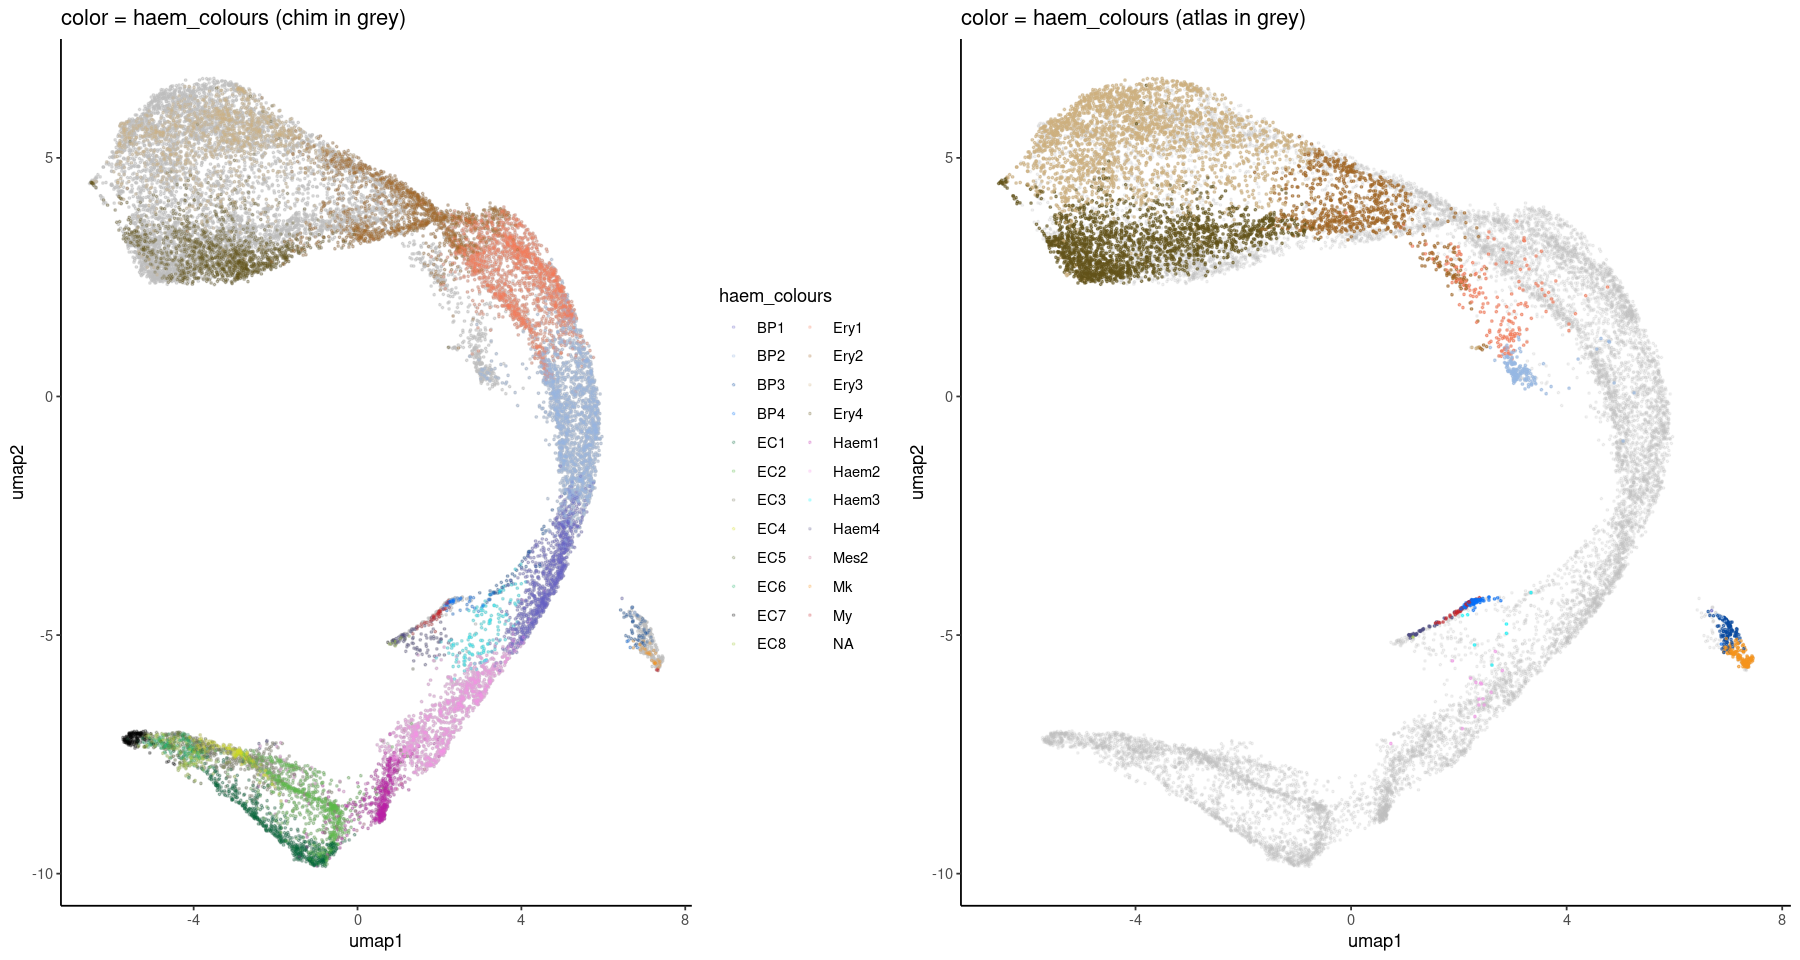

In [21]:
big_meta_85 <- big_meta # %>% filter(stage%in% c('E8.25','E8.5'))

p1 <- ggplot(big_meta_85, aes(umap1, umap2, color= haem_subclust.mapped)) +
    geom_point(alpha=0.5, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=haem_subclust),alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = haem_colours, labels = haem_labels, name = "haem_colours") +
    ggtitle('color = haem_colours (chim in grey)') #+
    #theme(legend.position = "none")
p2 <- ggplot(big_meta_85, aes(umap1, umap2, color=haem_subclust)) +
   geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=haem_subclust.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = haem_colours, labels = haem_labels, name = "haem_colours") +
    ggtitle('color = haem_colours (atlas in grey)') +
    theme(legend.position = "none")

options(repr.plot.width = 15, repr.plot.height = 8)
plot_grid(p1, p2)

In [22]:
png(paste0(plot_folder, "umap_celltype_mapping.png"), height=1000, width=1000)
    grid.arrange(p1, p2)
dev.off()

Warning message:
“Removed 5782 rows containing missing values (geom_point).”
Warning message:
“Removed 13881 rows containing missing values (geom_point).”


png 
  2

Warning message:
“Removed 13881 rows containing missing values (geom_point).”
Warning message:
“Removed 13881 rows containing missing values (geom_point).”


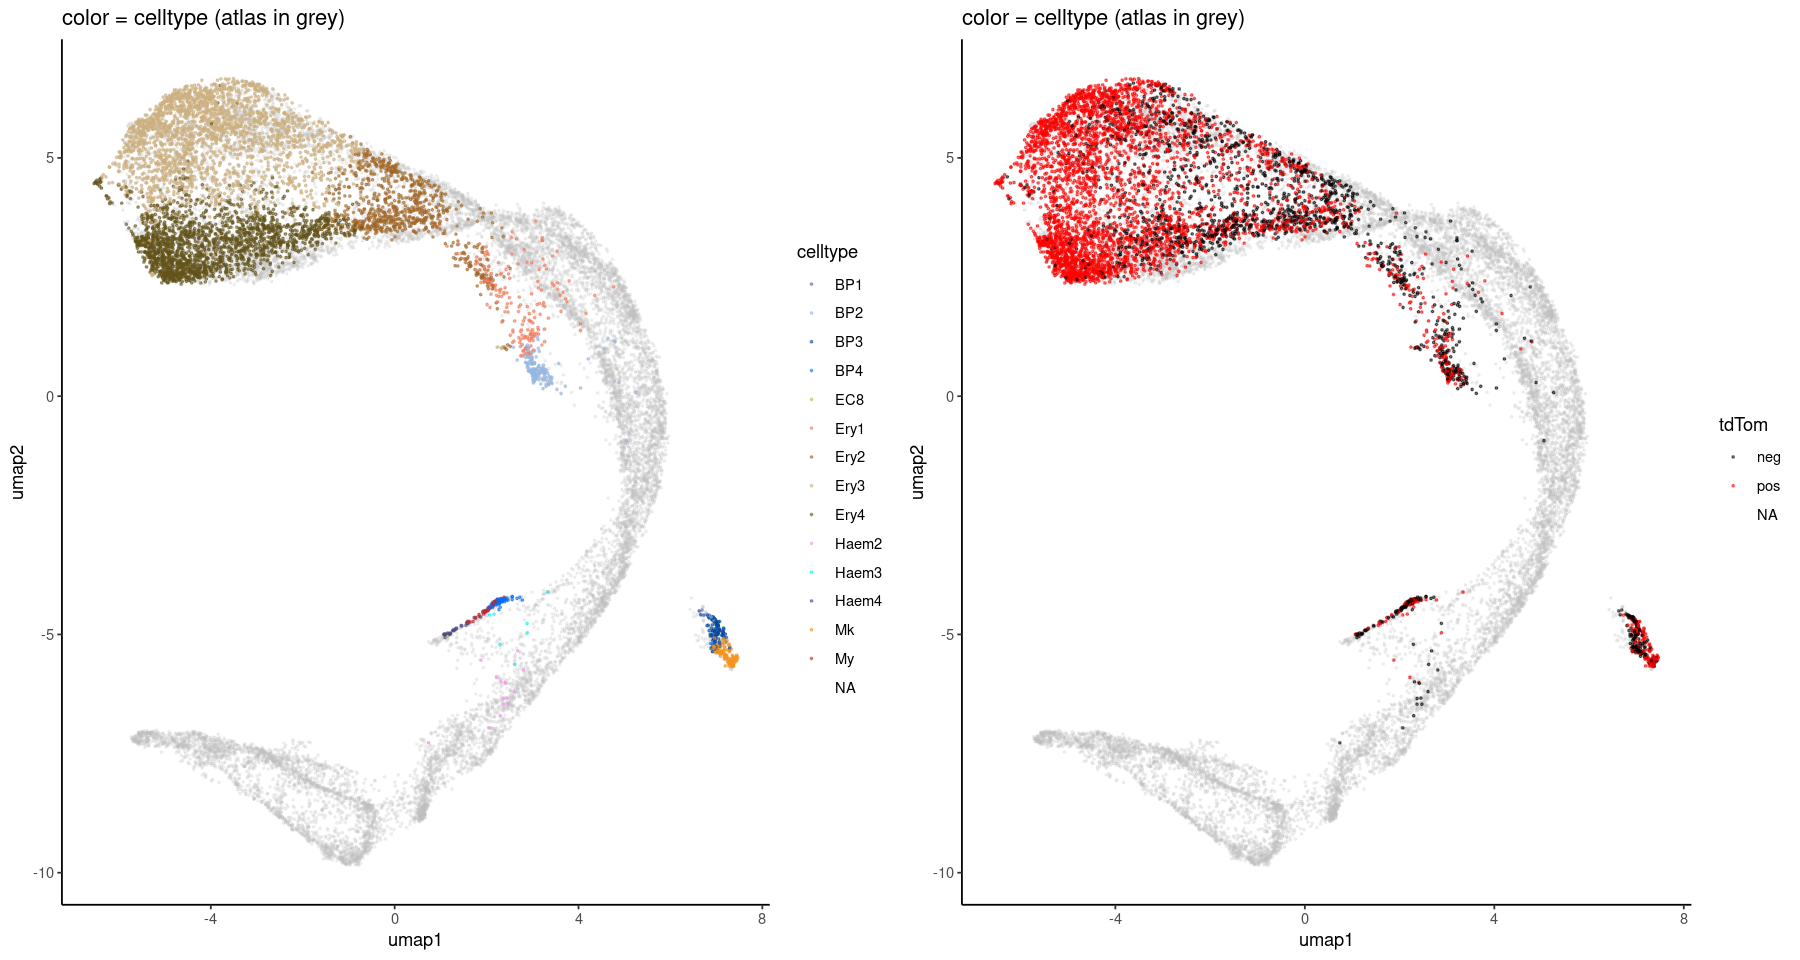

In [23]:
haem <- c( "Haematoendothelial progenitors",
                     "Endothelium",
                     "Blood progenitors 1",
                     "Blood progenitors 2",
                     "Erythroid1",
                     "Erythroid2",
                     "Erythroid3")
haem_plot <- big_meta %>% filter(celltype %in% haem | celltype.mapped %in% haem)
p1 <- ggplot(haem_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=haem_plot,aes(color=haem_subclust.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = haem_colours, labels = haem_labels, name = "celltype") +
    ggtitle('color = celltype (atlas in grey)')

p2 <- ggplot(haem_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=haem_plot,aes(color=tdTom),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) + 
    ggtitle('color = celltype (atlas in grey)')
                        
grid.arrange(p1, p2, nrow=1)

In [24]:

png(paste0(plot_folder, "umap_haem_mapping.png"), height=750, width=500)
    grid.arrange(p1, p2, nrow = 2)
dev.off()

Warning message:
“Removed 13881 rows containing missing values (geom_point).”
Warning message:
“Removed 13881 rows containing missing values (geom_point).”


png 
  2

#### Integration